[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_machine_learning/A1_pytorch_foundations.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A1 (ML) — PyTorch Foundations

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–90 min · **Difficulty:** Intermediate → Advanced

Modules 4 and 5 cover *classical* ML and prompt-driven *AI engineering*. This three-notebook PyTorch mini-track sits between them: when scikit-learn isn't enough and you need to train your own neural network — for tabular regression, image classification, sequence modelling, or fine-tuning a small transformer — PyTorch is the de-facto tool.

This first notebook gives you the **non-negotiable foundations**: tensors, autograd, modules, optimisers, training loops. By the end you'll train an MLP on tabular data and understand every line.

---

## 🎯 Learning objectives
- Manipulate `torch.Tensor` with confidence (shapes, devices, dtypes, autograd).
- Build models with `nn.Module` and train them with the canonical training loop.
- Diagnose and avoid the four classic bugs: NaN loss, frozen gradients, leaked test data, wrong device.
- Train a small MLP on a real tabular dataset and beat a logistic-regression baseline.

## ✅ Prerequisites
- Notebooks 1–9 (Python fluency + NumPy + matplotlib).
- Notebook 14 (`14_sklearn_basics.ipynb`) for the scikit-learn baseline.
- Optional: Notebook 16 (feature engineering).

## 📦 Install

```bash
pip install torch --index-url https://download.pytorch.org/whl/cpu     # CPU-only build, ~250 MB
# Or for a CUDA-enabled GPU:
# pip install torch --index-url https://download.pytorch.org/whl/cu121
```


## 1. Smoke test — is PyTorch available?

The whole notebook checks `HAS_TORCH` and skips runtime cells gracefully if torch isn't installed. The *code is still there* for you to read.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__}  ·  CUDA available: {torch.cuda.is_available()}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)
    print("Install with:  pip install torch --index-url https://download.pytorch.org/whl/cpu")


PyTorch 2.12.0  ·  CUDA available: False


## 2. Tensors — the only data structure you need

A `torch.Tensor` is a multi-dimensional array that *also* tracks gradients. Three things you'll do constantly:


In [2]:
if HAS_TORCH:
    # (a) Construction
    a = torch.zeros(2, 3)
    b = torch.randn(2, 3)
    c = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
    print("a:", a.shape, a.dtype, "·  b:", b.shape, "·  c:", c.tolist())

    # (b) Shape gymnastics — view / reshape / unsqueeze / transpose
    x = torch.arange(12).reshape(3, 4)              # 3×4
    print("view(2,6):", x.view(2, 6).shape)
    print("unsqueeze(0):", x.unsqueeze(0).shape)   # 1×3×4 (add batch axis)
    print("permute(1,0):", x.permute(1, 0).shape)  # 4×3

    # (c) Device & dtype
    x = torch.randn(3, 3, dtype=torch.float32)
    x_cpu = x.to("cpu")
    # x_gpu = x.to("cuda")   # only if CUDA is available
    print("device:", x_cpu.device, "dtype:", x_cpu.dtype)


a: torch.Size([2, 3]) torch.float32 ·  b: torch.Size([2, 3]) ·  c: [[1.0, 2.0], [3.0, 4.0]]
view(2,6): torch.Size([2, 6])
unsqueeze(0): torch.Size([1, 3, 4])
permute(1,0): torch.Size([4, 3])
device: cpu dtype: torch.float32


## 3. Autograd in one minute

Set `requires_grad=True` and PyTorch records every operation. Call `.backward()` to fill `.grad` with $\partial L / \partial \text{param}$ — that's all it takes.


In [3]:
if HAS_TORCH:
    x = torch.tensor(2.0, requires_grad=True)
    y = x ** 3 + 2 * x + 1     # y = x³ + 2x + 1
    y.backward()
    print("y =", y.item())
    print("dy/dx at x=2.0 :", x.grad.item(), "(expected 3·4 + 2 = 14)")

    # Gradients accumulate — always zero them before the next backward:
    x.grad.zero_()


y = 13.0
dy/dx at x=2.0 : 14.0 (expected 3·4 + 2 = 14)


**Why does this matter?** Every neural-network training loop is just `(compute loss) → loss.backward() → optimiser.step()`. Autograd computes *all* the gradients for *all* the parameters automatically, no matter how complex the model.

⚠️ **Pitfall #1 — gradients accumulate.** If you forget `optimizer.zero_grad()`, your gradients from the previous step get added in. The model will slowly diverge and you'll spend an afternoon staring at it.


## 4. A model in 6 lines — `nn.Module`

Subclass `nn.Module`, register layers in `__init__`, write the forward pass. That's it.


In [4]:
if HAS_TORCH:
    class MLP(nn.Module):
        def __init__(self, in_dim, hidden, out_dim, p_drop=0.1):
            super().__init__()
            self.fc1  = nn.Linear(in_dim, hidden)
            self.fc2  = nn.Linear(hidden, hidden)
            self.fc3  = nn.Linear(hidden, out_dim)
            self.drop = nn.Dropout(p_drop)
        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = self.drop(F.relu(self.fc2(x)))
            return self.fc3(x)

    model = MLP(in_dim=10, hidden=64, out_dim=1)
    print(model)
    print("Parameter count:", sum(p.numel() for p in model.parameters()))


MLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
)
Parameter count: 4929


**Mental model:** an `nn.Module` is a *registry* — every `nn.Linear` you assign to `self.x` automatically appears in `.parameters()`. The optimiser updates exactly what's in that list.

💡 **Tip.** Print the model before training — the architecture summary catches at least 1 in 3 bugs (wrong dim, missing activation, accidental `nn.Identity` left in).


## 5. The canonical training loop

Memorise this skeleton. Every PyTorch training script you ever read is a variation on it.


In [5]:
if HAS_TORCH:
    # Tiny synthetic regression task: y = 2*x0 - 3*x1 + 0.5*x2 + noise
    torch.manual_seed(0)
    N, D = 1000, 3
    X = torch.randn(N, D)
    y = (2*X[:,0] - 3*X[:,1] + 0.5*X[:,2] + 0.1*torch.randn(N)).unsqueeze(1)

    # Train/val split
    n_tr = int(0.8 * N)
    X_tr, X_va = X[:n_tr], X[n_tr:]
    y_tr, y_va = y[:n_tr], y[n_tr:]

    model     = MLP(in_dim=D, hidden=32, out_dim=1, p_drop=0.0)
    optim     = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn   = nn.MSELoss()

    history = []
    for epoch in range(200):
        # (1) forward + loss
        model.train()
        pred = model(X_tr)
        loss = loss_fn(pred, y_tr)
        # (2) backward
        optim.zero_grad()
        loss.backward()
        # (3) step
        optim.step()
        # (4) eval
        if epoch % 20 == 0 or epoch == 199:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_va), y_va).item()
            history.append((epoch, loss.item(), val_loss))

    for e, tr, va in history:
        print(f"epoch {e:3d}  train MSE {tr:.4f}  val MSE {va:.4f}")


epoch   0  train MSE 12.9160  val MSE 13.3276
epoch  20  train MSE 1.1693  val MSE 0.6801
epoch  40  train MSE 0.1985  val MSE 0.2013
epoch  60  train MSE 0.0435  val MSE 0.0594
epoch  80  train MSE 0.0221  val MSE 0.0274
epoch 100  train MSE 0.0163  val MSE 0.0220
epoch 120  train MSE 0.0147  val MSE 0.0202
epoch 140  train MSE 0.0136  val MSE 0.0192
epoch 160  train MSE 0.0128  val MSE 0.0184
epoch 180  train MSE 0.0122  val MSE 0.0178
epoch 199  train MSE 0.0117  val MSE 0.0171


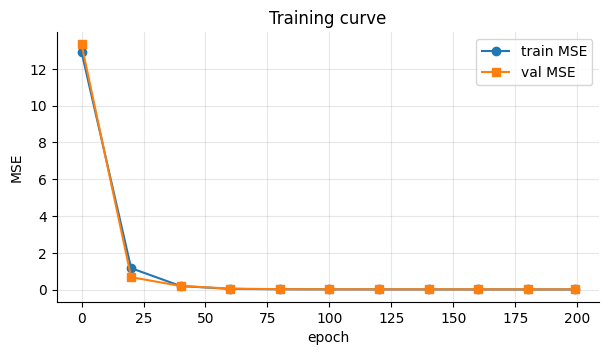

In [6]:
if HAS_TORCH:
    h = np.array(history)
    plt.figure(figsize=(7, 3.5))
    plt.plot(h[:,0], h[:,1], "o-", label="train MSE")
    plt.plot(h[:,0], h[:,2], "s-", label="val MSE")
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Training curve")
    plt.show()


**Read each block again.** Forward → loss → `zero_grad` → `backward` → `step`. The order matters: zero out, then accumulate fresh gradients, then step. Skipping `model.eval()` during validation leaves dropout *on*, which hurts your reported numbers.

⚠️ **Pitfall #2 — `model.train()` vs `model.eval()`.** These toggle dropout & batch-norm running statistics. Forget the switch and your validation loss becomes noisy/biased.


## 6. DataLoaders — batching done right

For real datasets you can't feed everything at once. `Dataset` + `DataLoader` give you mini-batches, shuffling, and parallel loading.


In [7]:
if HAS_TORCH:
    from torch.utils.data import TensorDataset, DataLoader

    ds_tr = TensorDataset(X_tr, y_tr)
    ds_va = TensorDataset(X_va, y_va)
    dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=256)

    model = MLP(D, 32, 1, p_drop=0.0)
    optim = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn = nn.MSELoss()

    for epoch in range(20):
        model.train()
        for xb, yb in dl_tr:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optim.step()
    model.eval()
    with torch.no_grad():
        val = sum(loss_fn(model(xb), yb).item() * xb.size(0) for xb, yb in dl_va) / len(ds_va)
    print(f"final val MSE after mini-batch training: {val:.4f}")


final val MSE after mini-batch training: 0.0287


For pandas/NumPy tabular data, the easiest pattern is `TensorDataset(torch.from_numpy(X_np).float(), torch.from_numpy(y_np).float())`. For images use `torchvision.datasets.ImageFolder`; for text, `torch.utils.data.Dataset` subclass that tokenises on the fly.


## 7. A real tabular dataset — beat the logistic baseline

We'll use scikit-learn's `make_classification` so the notebook runs anywhere. The pattern transfers directly to your own CSV: load → scale → tensors → DataLoader → train.


In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=4, n_classes=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

# (1) Sklearn baseline
clf = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
p_te = clf.predict_proba(X_te_s)[:, 1]
print(f"Logistic baseline  ·  acc={accuracy_score(y_te, p_te > 0.5):.3f}  AUC={roc_auc_score(y_te, p_te):.3f}")


Logistic baseline  ·  acc=0.764  AUC=0.848


In [9]:
if HAS_TORCH:
    from torch.utils.data import TensorDataset, DataLoader

    def to_tensor(a, dtype=torch.float32): return torch.from_numpy(a).to(dtype)
    Xtr = to_tensor(X_tr_s); ytr = to_tensor(y_tr, torch.float32).unsqueeze(1)
    Xte = to_tensor(X_te_s); yte = to_tensor(y_te, torch.float32).unsqueeze(1)

    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    class TabularMLP(nn.Module):
        def __init__(self, in_dim, hidden=64, p_drop=0.2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, 1),
            )
        def forward(self, x): return self.net(x)

    model = TabularMLP(in_dim=Xtr.shape[1])
    optim = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(40):
        model.train()
        for xb, yb in dl_tr:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb); loss.backward(); optim.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte)).squeeze().numpy()
    print(f"MLP  ·  acc={accuracy_score(y_te, probs > 0.5):.3f}  AUC={roc_auc_score(y_te, probs):.3f}")


MLP  ·  acc=0.938  AUC=0.986


**Notice the API parity.** `BCEWithLogitsLoss` does sigmoid + binary cross-entropy in one numerically-stable operation. `AdamW` is the default optimiser for most deep-learning work today (Adam with decoupled weight decay). Three things to remember:

| Block | Replace with for… |
|---|---|
| `nn.BCEWithLogitsLoss` | binary classification |
| `nn.CrossEntropyLoss` | multi-class classification (no softmax in the model) |
| `nn.MSELoss` / `nn.L1Loss` | regression |


## 8. Saving and loading models

Two patterns. Use the second one in production.


In [10]:
if HAS_TORCH:
    # (a) Quick — pickle the whole model object (fragile; ties to your class definition)
    # torch.save(model, "model.pt")
    # model2 = torch.load("model.pt")

    # (b) Recommended — save just the state_dict (the weights), reconstruct the class separately:
    torch.save(model.state_dict(), "/tmp/tab_mlp_state.pt")
    model2 = TabularMLP(in_dim=Xtr.shape[1])
    model2.load_state_dict(torch.load("/tmp/tab_mlp_state.pt"))
    model2.eval()
    with torch.no_grad():
        same = torch.allclose(model(Xte), model2(Xte))
    print("reloaded model produces identical outputs:", same)


reloaded model produces identical outputs: True


## 9. The four bugs you will hit

| Symptom | Cause | Fix |
|---|---|---|
| **NaN loss after epoch 1** | LR too high, or `log(0)` in custom loss | Lower `lr`, use `BCEWithLogitsLoss` not raw `BCELoss` |
| **Loss is flat** | Gradients zero — wrong dtype, frozen layer, missing `requires_grad` | Print `param.grad.norm()` per layer |
| **Val loss < train loss** (suspicious) | Data leak; you're scaling using *all* X | Fit the scaler on train only |
| **CUDA out of memory** | Batch too big, or you forgot `with torch.no_grad()` in eval | Reduce batch, use `no_grad` for inference |

A surprising amount of debugging happens *before* training even starts — print shapes, dtypes, and parameter counts at construction time.


## 🧪 Exercises

### Exercise 1 — Add early stopping
The training loop above runs a fixed number of epochs. Add **early stopping** on the validation loss: track the best val loss so far, stop if it doesn't improve for `patience=5` epochs, and restore the best weights at the end.


In [11]:
if HAS_TORCH:
    # ── Exercise 1 solution ──────────────────────────────────────────────
    import copy
    def train_with_early_stop(dl_tr, X_va, y_va, in_dim, max_epochs=100, patience=5, lr=3e-3):
        model = TabularMLP(in_dim=in_dim)
        opt   = torch.optim.AdamW(model.parameters(), lr=lr)
        loss_fn = nn.BCEWithLogitsLoss()
        best_state, best_va, wait = None, float("inf"), 0
        for epoch in range(max_epochs):
            model.train()
            for xb, yb in dl_tr:
                opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
            model.eval()
            with torch.no_grad():
                va = loss_fn(model(X_va), y_va).item()
            if va < best_va - 1e-4:
                best_va, best_state, wait = va, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"stopping at epoch {epoch}; best val loss = {best_va:.4f}")
                    break
        model.load_state_dict(best_state)
        return model, best_va

    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    best_model, best_va = train_with_early_stop(dl, Xte, yte, in_dim=Xtr.shape[1])


stopping at epoch 22; best val loss = 0.1850


### Exercise 2 — Compare to a much smaller MLP
Train a tiny MLP (one hidden layer with 8 units, no dropout). On this dataset, do you get a better or worse AUC than the 2-hidden-layer MLP? What does that tell you about *model capacity* vs *dataset size*?


In [12]:
if HAS_TORCH:
    # ── Exercise 2 solution ──────────────────────────────────────────────
    class TinyMLP(nn.Module):
        def __init__(self, in_dim):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(in_dim, 8), nn.ReLU(), nn.Linear(8, 1))
        def forward(self, x): return self.net(x)

    m = TinyMLP(Xtr.shape[1])
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()
    for epoch in range(60):
        m.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        probs = torch.sigmoid(m(Xte)).squeeze().numpy()
    print(f"Tiny MLP   ·  AUC={roc_auc_score(y_te, probs):.3f}")
    # Comment: with only 2000 rows and 20 features the dataset is small —
    # a bigger MLP overfits faster; a tiny one with dropout-free training
    # often performs comparably. More capacity helps when *data* grows.


Tiny MLP   ·  AUC=0.962


## 🧠 Key takeaways

- Tensors + autograd + `nn.Module` + an optimiser = everything you need.
- The training loop is **always** the same five lines: forward → loss → `zero_grad` → `backward` → `step`.
- Use `BCEWithLogitsLoss`/`CrossEntropyLoss`/`MSELoss` — not their numerically-unstable cousins.
- Save the **state_dict**, not the whole model object.
- Most bugs are detected by *printing shapes & gradients* before you blame the math.

## 🚀 Next step

[`A2_pytorch_vision_and_sequences.ipynb`](./A2_pytorch_vision_and_sequences.ipynb) — CNNs for images, RNNs and a small Transformer for sequences.
